### 라이브러리 선언

In [1]:
# 데이터처리 라이브러리
import pandas as pd
import numpy as np

# 데이터 전처리 라이버리
from sklearn.model_selection import train_test_split

In [2]:
# 딥러닝 라이브러리
import tensorflow as tf
from tensorflow import keras

In [3]:
from sklearn.preprocessing import MinMaxScaler

### 데이터 불러오기

In [4]:
gitUrl = "https://raw.githubusercontent.com/hyokwan/python-lecture/master/dataset/feature_regression_example.csv"
featuresData = pd.read_csv(gitUrl)

# A. 데이터 전처리

### 1.타입 통합 및 숫자형 컬럼 추가

In [5]:
### 타입 통합 (테이블정의서 동일하게 데이터타입을 맞추는작업)

In [6]:
### 숫자형 컬럼 추가
ynMap = {"N":0, "Y":1}
featuresData["HOLIDAY_LE"] = featuresData.HOLIDAY.map(ynMap )
featuresData["PROMOTION_LE"] = featuresData.PROMOTION.map(ynMap )
featuresData.head(2)

,REGIONID,PRODUCTGROUP,PRODUCT,ITEM,YEARWEEK,YEAR,WEEK,QTY,HOLIDAY,HCLUS,PROMOTION,PRO_PERCENT,HOLIDAY_LE,PROMOTION_LE
0,SEOUL_BANK_001,PG02,PRODUCT0010,ITEM0115,201501,2015,1,1225,Y,1,Y,0.209442,1,1
1,SEOUL_BANK_001,PG02,PRODUCT0010,ITEM0115,201502,2015,2,968,N,4,Y,0.209442,0,1


In [7]:
hclustScaler = MinMaxScaler()
propercentScaler = MinMaxScaler()
promotionScaler = MinMaxScaler()
holidayScaler = MinMaxScaler()

In [8]:
featuresData["HCLUS_SCALE"] = hclustScaler.fit_transform( featuresData.loc[ :, ["HCLUS"]] )
featuresData["PROPERCENT_SCALE"] = propercentScaler.fit_transform( featuresData.loc[ :, ["PRO_PERCENT"]] )
featuresData["PROMOTION_SCALE"] = promotionScaler.fit_transform( featuresData.loc[ :, ["PROMOTION_LE"]] )
featuresData["HOLIDAY_SCALE"] = holidayScaler.fit_transform( featuresData.loc[ :, ["HOLIDAY_LE"]] )

### 2. 특성선정 및 데이터 분리

In [9]:
label = ["QTY"]

In [10]:
features = list ( featuresData.select_dtypes(np.number).columns )

In [11]:
features.remove(label[0])

In [12]:
features = ["HCLUS_SCALE","PROPERCENT_SCALE","PROMOTION_SCALE","HOLIDAY_SCALE"]

In [13]:
trainData, testData = train_test_split( featuresData, test_size=0.2, random_state=2)
trainDataFeatures = trainData.loc[ :, features]
trainDataLabel = trainData.loc[ :, label]
testDataFeatures = testData.loc[ :, features]
testDataLabel = testData.loc[ :, label]
print(trainDataFeatures.shape )
print(trainDataLabel.shape )
print(testDataFeatures.shape )
print(testDataLabel.shape )

(84, 4)
(84, 1)
(21, 4)
(21, 1)


# B. 모델 생성/훈련

### 3. 모델 생성

In [14]:
from sklearn import tree
dtModel = tree.DecisionTreeRegressor(random_state=10)

In [15]:
## 딥러닝 레이어를 층층으로 쌓겠다
from tensorflow.keras import Sequential
## 딥러닝 레이어중에서 : 전체연결하는 가장 기본레이어 : Dense
from tensorflow.keras.layers import Dense, Input

In [16]:
# 훈련데이터의 문제지를 활용해서 shape을 찾는다
# 인덱스로 0번째 인덱스를 찾은 후 한개행의 shape을 찾는다.
inputShape = trainDataFeatures.iloc[0].shape
inputShape

(4,)

In [17]:
unitSize = 64

In [18]:
# 모델 초기화
model = Sequential()
# #1. 인풋레이어 (input layer)
model.add( Input (shape = inputShape ) )
# #2. 히든레이어 (hidden layer)
model.add( Dense( units=unitSize, activation="relu"))
model.add( Dense( units=unitSize, activation="relu"))
# #3. 출력레이어 (output layer)
model.add( Dense( units=1, activation="relu"))

In [19]:
# 모델 초기화
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# # pyot 및 graphviz 설치 필요
# from tensorflow.keras.utils import plot_model

In [21]:
# plot_model( model, show_shapes=True)

### 4. 모델 컴파일

In [22]:
## 생성된 모델에 손실함수(loss_function) 및 최적화함수 (교수매핑: adam)
model.compile(loss="mean_squared_error",
              optimizer="adam",
              metrics=["mean_squared_error","mean_absolute_error"])

### 5. 모델 훈련

In [23]:
### 콜백함수는 모델 훈련 전에 설정한다.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from datetime import datetime

# 조기종료 용 콜백함수
callbackEarly = EarlyStopping(monitor="val_loss", patience=50)
# 베스트모델 별도 관리함수
modelCheck = ModelCheckpoint(filepath="./check/model_best.keras", 
                verbose=1, 
                monitor="val_loss", 
                save_best_only=True)
logDir = "logs/fit/"+datetime.now().strftime("%Y%m%d-%H%M%S")
print(logDir)
callbackTensor = TensorBoard( log_dir=logDir)

callbackList = [ callbackEarly, modelCheck, callbackTensor ]


logs/fit/20260911-161833


In [24]:
fittedDtModel = dtModel.fit(trainDataFeatures, trainDataLabel)

In [25]:
fittedModel = model.fit(x=trainDataFeatures,
                        y=trainDataLabel,
                        batch_size=32, 
                        epochs=500, 
                        validation_split=0.2,
                        callbacks=callbackList)

Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step - loss: 1738817.5000 - mean_absolute_error: 1106.4695 - mean_squared_error: 1738817.5000
Epoch 1: val_loss improved from None to 2096314.87500, saving model to ./check/model_best.keras

Epoch 1: finished saving model to ./check/model_best.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 1962300.0000 - mean_absolute_error: 1175.5852 - mean_squared_error: 1962300.0000 - val_loss: 2096314.8750 - val_mean_absolute_error: 1145.7721 - val_mean_squared_error: 2096314.8750
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2476554.7500 - mean_absolute_error: 1334.5377 - mean_squared_error: 2476554.7500
Epoch 2: val_loss improved from 2096314.87500 to 2095924.75000, saving model to ./check/model_best.keras

Epoch 2: finished saving model to ./check/model_best.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1961891.2500 - mean_absolute_error: 1175.4187 - mean_squared_error: 1961891.2500 - val_loss: 2095924.7500 - val_mean_absolute

### C. 데이터 정리

### 6. 데이터 예측

In [26]:
features

['HCLUS_SCALE', 'PROPERCENT_SCALE', 'PROMOTION_SCALE', 'HOLIDAY_SCALE']

In [27]:
inHclus = 1
inPropercent = 0.5
inPromotion = "Y"
inHoliday = "Y"

In [28]:
# 전처리 첫번째 
preprocessingFirst = [np.nan, np.nan, ynMap, ynMap]

In [29]:
inPromotion = ynMap[inPromotion]
inHoliday = ynMap[inHoliday]

In [ ]:
preprocessingSecond = [hclustScaler, propercentScaler, promotionScaler, holidayScaler]
loadedHclusScaler = preprocessingSecond[0]
inHclus = loadedHclusScaler.transform([[inHclus]])[0][0]
loadedPercentScaler = preprocessingSecond[1]
inPropercent = loadedPercentScaler.transform([[inPropercent]])[0][0]
loadedPromotionScaler = preprocessingSecond[2]
inPromotion = loadedPromotionScaler.transform([[inPromotion]])[0][0]
loadedHolidayScaler = preprocessingSecond[3]
inHoliday = loadedHolidayScaler.transform([[inHoliday]])[0][0]

In [36]:
testDf = pd.DataFrame( [[inHclus,inPropercent,inPromotion,inHoliday]] )

In [37]:
testDf

,0,1,2,3
0,0.25,1.185148,1.0,1.0


In [38]:
fittedDtModel.predict(testDf)

c:\Users\hk\fintech_data_2026\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([2106.75])

In [39]:
model.predict(testDf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


array([[1986.3214]], dtype=float32)

In [40]:
# mse mae mape 테스트데이터 (여러분들이 만들어볼 몫)

### 테스트 데이터 활용 예측 (작업과제 #1)

### 테스트 데이터 활용 정확도 측정 [MAE, RMSE, MAPE] (작업과제 #1)

### 학습 결과 그래프 Tensorboard 연동 (작업과제 #2)

### 학습 결과 서빙모델 생성 (작업과제 #3)

### 학습모델 저장

In [41]:
# 딥러닝 모델 저장 (# 딥러닝은 모델을 확장자 keras pt를 그대로 따라야하고 모델은 save함수로 저장 이외재료는 joblib로 저장 가능)
model.save("./check/model_last.keras")

In [42]:
# 부수 재료 저장
modelDict = {}

In [43]:
import joblib

In [44]:
modelDict["org_features"] = features
modelDict["new_features"] = features
modelDict["label"] = label
modelDict["preprocessing1"] = preprocessingFirst
modelDict["preprocessing2"] = preprocessingSecond

In [45]:
joblib.dump(modelDict, "./check/model_info.dump")

['./check/model_info.dump']

In [46]:
### 1. 모델을 경합 (머신러닝/딥러닝)
### (mse, mae, mape) : 숫자를 예측하는 모델이였으니깐
### 2. 학습이 되었는지 확인하는 그래프를 보여줘야한다.
### tensorboard 캡쳐
### 3. 서빙모델을 만들어본다.  --- 여기까진 꼭 해보기
### 모델 + 모델 부가옵션데이터를 들고 가야함 (전처리함수 포함)
### 4. 데이터를 변경해서.. (안한게..라벨링을할때 )
### 예를: 컬럼에 회사정보가 있어 samsung, lg, costco, bestbuy 30개
### 요청: (데이터셋 숫자로좀 바꿔줘!!!) 어떻게 라벨링를 30개... labelEncoder (취약점)
###       labelEncoder: 처음(데이터를 오름차순정렬 후 0부터 라벨링 시작)

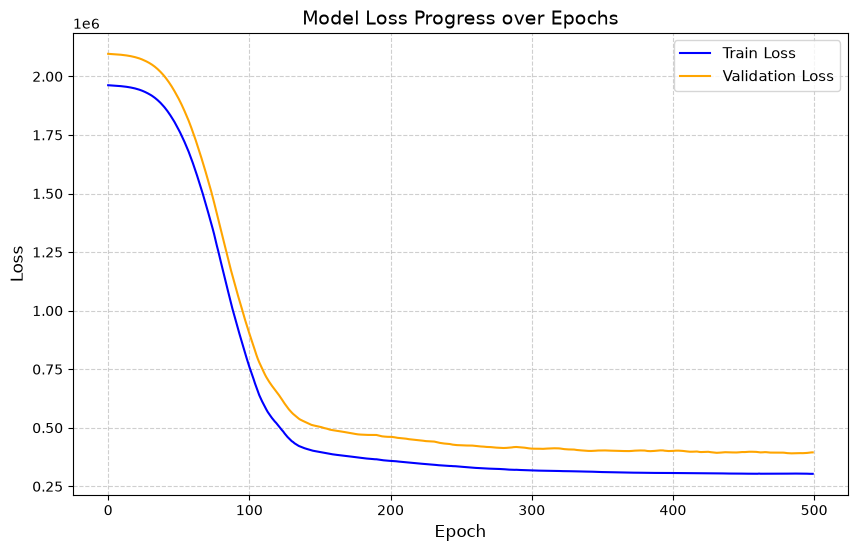

In [47]:
import matplotlib.pyplot as plt

# 차트 크기 설정
plt.figure(figsize=(10, 6))

# loss 및 val_loss 시각화
plt.plot(fittedModel.history['loss'], label='Train Loss', color='blue')
plt.plot(fittedModel.history['val_loss'], label='Validation Loss', color='orange')

# 축 및 제목 설정
plt.title('Model Loss Progress over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 차트 출력
plt.show()